## 1. Projenin Amacı

Bu projede Netflix içerik veri seti analiz edilerek platformdaki film ve dizilerin dağılımı, yıllara göre içerik 
artışı, ülke bazlı üretim, içerik türleri ve yaş sınıflandırmaları incelenmiştir.

## 2. Gerekli Kütüphaneler

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

## 3. Veri Setinin Yüklenmesi

In [2]:
df = pd.read_csv("netflix_titles.csv")

## 4. Veri Setinin İlk İncelenmesi

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Veri setinin ilk 5 satırı incelenerek kolon yapısı hakkında genel bilgi edinilir.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Veri tipleri ve eksik değerler gözlemlenir.

In [5]:
df.shape

(8807, 12)

Veri setinin satır ve sütunu hakkında bilgi edinilir.

In [6]:
df[df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


Tekrar eden satırlar incelendi. Fazladan aynı satırımız yok.

## 5. Veri Temizleme

In [7]:
df.isnull().sum() / len(df) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

Her kolon için kayıp değerler incelendi ve direktör sütununda %30 luk kayıp verimiz var.  
Oyuncu ve ülke kolonlarında da %10 luk bir kayıp veri mevcut.

In [8]:
df["director"].value_counts(dropna=False)

director
NaN                                       2634
Rajiv Chilaka                               19
Raúl Campos, Jan Suter                      18
Suhas Kadav                                 16
Marcus Raboy                                16
                                          ... 
Milla Harrison-Hansley, Alicky Sussman       1
Drew Stone                                   1
Benjamin Turner                              1
S. Shankar                                   1
Peter Hewitt                                 1
Name: count, Length: 4529, dtype: int64

In [9]:
df[df["director"].isna()].sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7772,s7773,TV Show,Power Rangers S.P.D.,NaN,"Brandon Jay McLaren, Chris Violette, Matt Aust...","United States, New Zealand","January 1, 2016",2005,TV-Y7,1 Season,Kids' TV,"When the Troobian Empire attacks Earth, the B-..."
5672,s5673,TV Show,InuYasha,NaN,"Kappei Yamaguchi, Satsuki Yukino, Kumiko Watan...",Japan,"December 15, 2016",2001,TV-14,2 Seasons,"Anime Series, International TV Shows","Yanked down a well, schoolgirl Kagome Higurash..."
6198,s6199,TV Show,Aussie Gold Hunters,NaN,NaN,Australia,"August 1, 2017",2016,TV-MA,1 Season,"Docuseries, International TV Shows, Reality TV",Three teams of gold hunters battle all manner ...
7597,s7598,TV Show,North & South,NaN,"Daniela Denby-Ashe, Richard Armitage, Tim Pigo...",United Kingdom,"March 31, 2017",2004,NR,1 Season,"British TV Shows, Romantic TV Shows, TV Dramas",When her father moves his family to an industr...
3968,s3969,TV Show,The Terminal,NaN,"Mohammad Mansour, Bouthayna Al Raesi, Bassima ...",NaN,"March 29, 2019",2018,TV-14,1 Season,"International TV Shows, TV Dramas","Social pressure, a complicated past and a clas..."


`director` sütunu %30 kayıp veriye sahip olsa da diğer sütun verileri bizim için önemli olduğundan  
bu kolon için NaN değerlerini tutmayı tercih ediyorum.

In [10]:
df["cast"].value_counts(dropna=False)

cast
NaN                                                                                                                                                            825
David Attenborough                                                                                                                                              19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil                                                                         14
Samuel West                                                                                                                                                     10
Jeff Dunham                                                                                                                                                      7
                                                                                                                                                              ... 
Ali Suliman, Sale

`cast` sütunu için herhangi bir boş değer işlemi yapmadan geçiyorum.  
Çünkü analizimi çok etkileyebilecek bir kolon değil.

In [11]:
df["country"].value_counts(dropna=False)

country
United States                                             2818
India                                                      972
NaN                                                        831
United Kingdom                                             419
Japan                                                      245
                                                          ... 
Germany, Canada, United States                               1
Denmark, United Kingdom, South Africa, Sweden, Belgium       1
Serbia, South Korea, Slovenia                                1
United Kingdom, Spain, Belgium                               1
South Africa, United States, Japan                           1
Name: count, Length: 749, dtype: int64

`country` sütunu için de herhangi bir doldurma veya silme işlemi yapmıyorum.  
Analizimiz için önemli bir kolon. Ve doldurmak veya silmek mantıklı değil.

In [12]:
df["date_added"].value_counts(dropna=False)

date_added
January 1, 2020      109
November 1, 2019      89
March 1, 2018         75
December 31, 2019     74
October 1, 2018       71
                    ... 
 June 1, 2018          1
October 21, 2018       1
February 8, 2016       1
June 5, 2018           1
October 14, 2017       1
Name: count, Length: 1768, dtype: int64

In [13]:
df["date_added"] = df["date_added"].str.strip()

In [14]:
df[df["date_added"].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,NaN,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


`date_added`  kolonu için herhangi bir silme veya doldurma işlemi yapmıyorum.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [16]:
df["date_added"] = pd.to_datetime(df["date_added"])

`date_added` sütunun veri tipini tarih formatına çevirdim,  
bu şekilde aylık, günlük ve yıllık olarak eklenme zamanları üstünden analiz yapabilirim.

In [17]:
df[["date_added","release_year"]].sample(5)

,date_added,release_year
6025,2019-05-15,2018
6920,2018-01-01,2017
5579,2017-03-10,2017
8048,2019-03-19,2018
2051,2020-09-03,2018


## 6. Feature Engineering

### 6.1 Film ve Dizi Süresi Özelliğinin Oluşturulması

In [18]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [19]:
movie_mask = df["type"]=='Movie'

In [20]:
tv_mask = df["type"]=='TV Show'

In [21]:
df.loc[movie_mask, "duration"]

0        90 min
6        91 min
7       125 min
9       104 min
12      127 min
         ...   
8801     96 min
8802    158 min
8804     88 min
8805     88 min
8806    111 min
Name: duration, Length: 6131, dtype: object

In [22]:
df["movie_duration"] = df.loc[movie_mask, "duration"].str.extract(r'(\d+)')
df["season_count"] = df.loc[tv_mask, "duration"].str.extract(r'(\d+)')

`duration` sütunundan film olan verilerin sürelerini ayrı bir kolon olarak ekledim.  
Aynı şekilde `duration` kolonundan TV Show olan dizilerden sezon sayılarını çekerek  
ileri analiz için yeni iki feature sütun oluşturdum.

In [23]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,movie_duration,season_count
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,1
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN,1
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN,2


### 6.2 Tarih Özelliklerinin Oluşturulması

In [24]:
df["added_day_name"] = df["date_added"].dt.day_name()
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month_name()


In [25]:
df["added_year"] = pd.to_numeric(df["added_year"], errors="coerce").astype("Int64")

In [26]:
df.head(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,movie_duration,season_count,added_day_name,added_year,added_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,NaN,Saturday,2021,September


## 7. Keşifsel Veri Analizi (EDA)

### Soru 1: Netflix kataloğunda dizi mi fazla film mi?

In [27]:
count_shows = df.groupby("type")["show_id"].count()
count_shows

type
Movie      6131
TV Show    2676
Name: show_id, dtype: int64

C:\Users\RAMAZAN EROĞLU\AppData\Local\Temp\ipykernel_15872\3417877123.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=11,color="black",weight="normal")
C:\Users\RAMAZAN EROĞLU\AppData\Local\Temp\ipykernel_15872\3417877123.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)


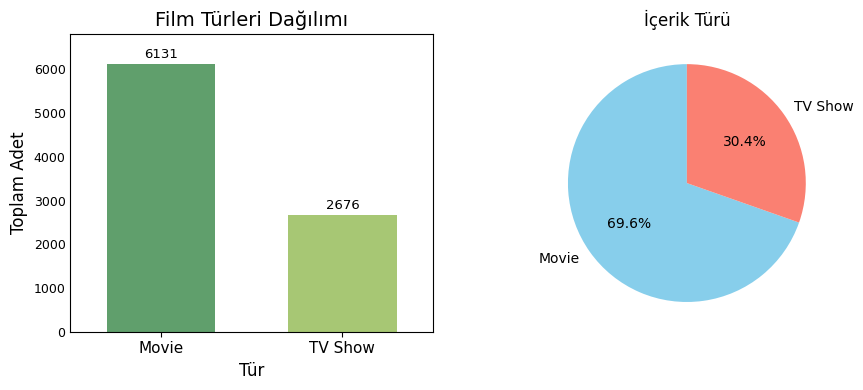

In [28]:

fig , (ax, ax2) = plt.subplots(1, 2, figsize=(9,4))
ax2.pie(count_shows.values, colors=["skyblue","salmon"], labels=count_shows.index, autopct='%1.1f%%',startangle=90,
         textprops={"fontsize":10, "color":"black", "weight":"normal"})
ax2.set_title("İçerik Türü",fontsize=12, color="black")


sns.barplot(x=count_shows.index, y = count_shows.values, ax=ax, hue=count_shows.index, legend=False, palette="summer",width=0.6)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=1.7, color="black", fontsize=9.5)
ax.set_title("Film Türleri Dağılımı",fontsize=14, color="black")
ax.set_ylabel("Toplam Adet", fontsize=12, color="black")
ax.set_xlabel("Tür", fontsize=12, color="black")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11,color="black",weight="normal")  
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
ax.yaxis.grid(False)
ax.tick_params(axis="y", which="both", length=0) # y eksenindeki kısa çizgileri kaybeder.
ax.set_ylim(0,6800)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

Netflix içeriklerinin yaklaşık %70 i (6131) filmlerden %30 u (2676) ise TV Show larından oluşuyor.

### Soru 2: Netflix hangi yıllarda en fazla içerik ekledi?

In [29]:
added_years = df["added_year"].value_counts(dropna=True).sort_index(ascending=False)
added_years

added_year
2021    1498
2020    1879
2019    2016
2018    1649
2017    1188
2016     429
2015      82
2014      24
2013      11
2012       3
2011      13
2010       1
2009       2
2008       2
Name: count, dtype: Int64

C:\Users\RAMAZAN EROĞLU\AppData\Local\Temp\ipykernel_15872\4046689839.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(),fontsize=9)


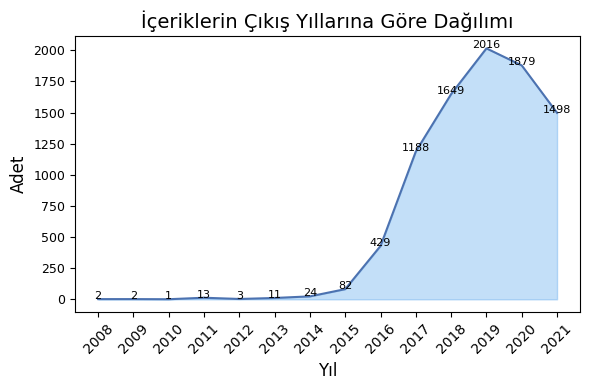

In [30]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(added_years.index,added_years.values, color="#4C72B0")
ax.set_title("İçeriklerin Çıkış Yıllarına Göre Dağılımı", fontsize=14, color="black")
ax.set_xlabel("Yıl",fontsize=12, color="black")
ax.set_ylabel("Adet",fontsize=12, color="black")
ax.set_xticks(range(2008, 2022, 1))  
ax.set_xticklabels(range(2008, 2022, 1), fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_yticklabels(ax.get_yticklabels(),fontsize=9)
ax.fill_between(added_years.index,added_years.values, 0, color="#3B95E9", alpha=0.3)
for x, y in zip(added_years.index,added_years.values):
    plt.text(x, y+0.5, str(y), ha="center", fontsize=8, color="black")
plt.grid(False)
plt.tight_layout()
plt.show()

İçeriklerin yıllara göre çıkış dağılımına baktığımızda 2008-2014 arası süre sabit ve düşük iken  
2014 ten sonra 2019 a kadar yüksek derecede artış olduğu görülüyor.  
2019 sonrası ise % 30 luk içerik yüklemesinde düşüş var.

In [31]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


### Soru 3: İçeriklerin gerçek yılı nasıl dağılır?

In [32]:
release_year_ = df["release_year"].value_counts().sort_index(ascending=False).head(22)
release_year_

release_year
2021     592
2020     953
2019    1030
2018    1147
2017    1032
2016     902
2015     560
2014     352
2013     288
2012     237
2011     185
2010     194
2009     152
2008     136
2007      88
2006      96
2005      80
2004      64
2003      61
2002      51
2001      45
2000      37
Name: count, dtype: int64

C:\Users\RAMAZAN EROĞLU\AppData\Local\Temp\ipykernel_15872\2522240373.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(),fontsize=7)


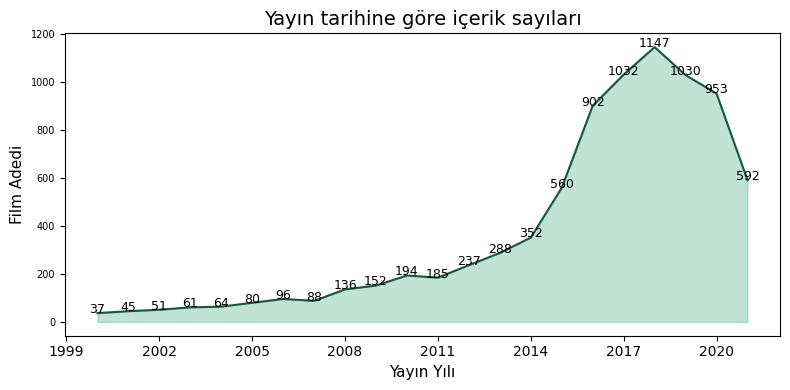

In [33]:
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(release_year_.index, release_year_.values, color="#13593E")
ax.set_title("Yayın tarihine göre içerik sayıları",color="black", fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(),fontsize=7)
ax.set_xticks(range(1999, 2022, 3)) 
ax.set_xticklabels(range(1999, 2022, 3), fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_xlabel("Yayın Yılı",fontsize=11)
ax.fill_between(release_year_.index, release_year_.values, 0, color="#34A47A", alpha=0.3)
ax.set_ylabel("Film Adedi",fontsize=11)
for x, y in zip(release_year_.index, release_year_.values):
    plt.text(x, y+0.5, str(y), ha="center", fontsize=9, color="black")
plt.tight_layout()
plt.show()


2000 yılı ile beraber film ve dizi sektöründe içerik yapımları artarak 2018 yılında  
1147 içerik yayını ile en yüksek seviyesine ulaşmaktadır. 2019-2021 arası ise 
içerik üretiminde azalma görülmektedir.

### Soru 4: Netflix'e hangi aylarda daha fazla içerik ekleniyor?

In [34]:
month_order = ["January", "February", "March", "April", "May", "June",
             "July", "August", "September", "October", "November", "December"]

In [35]:
count_month = df["added_month"].value_counts()
count_month = count_month.reindex(month_order,fill_value=0)
count_month

added_month
January      738
February     563
March        742
April        764
May          632
June         728
July         827
August       755
September    770
October      760
November     705
December     813
Name: count, dtype: int64

C:\Users\RAMAZAN EROĞLU\AppData\Local\Temp\ipykernel_15872\4259730920.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


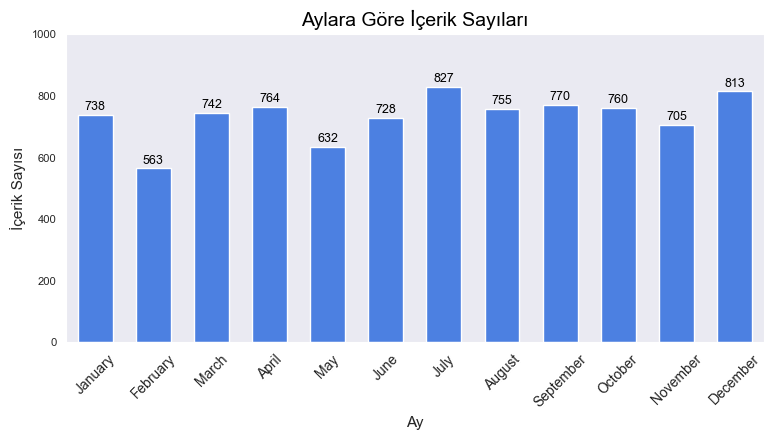

In [36]:
sns.set_style("dark")
fig, ax = plt.subplots(figsize=(9,4))

sns.barplot(x=count_month.index, y=count_month.values, ax=ax,width=0.6, color="#3378FA")
ax.set_title("Aylara Göre İçerik Sayıları",fontsize=14,color="black")
ax.set_ylabel("İçerik Sayısı",fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=1.7, color="black", fontsize=9)
ax.tick_params(axis="y", labelsize=8) 
ax.set_xlabel("Ay",fontsize=11)
ax.set_ylim([0,1000])
plt.show()

Aylara göre içerik sayılarına baktığımızda temmuz ve aralık aylarında daha fazla  
içerik eklenirken genel olarak aylar arasında çok bir fark olmadığı gözleniyor.

### Soru 5: En yaygın içerik derecelendirmeleri (Rating) hangileri?

In [37]:
popular_rating = df["rating"].value_counts().head(10)
popular_rating

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

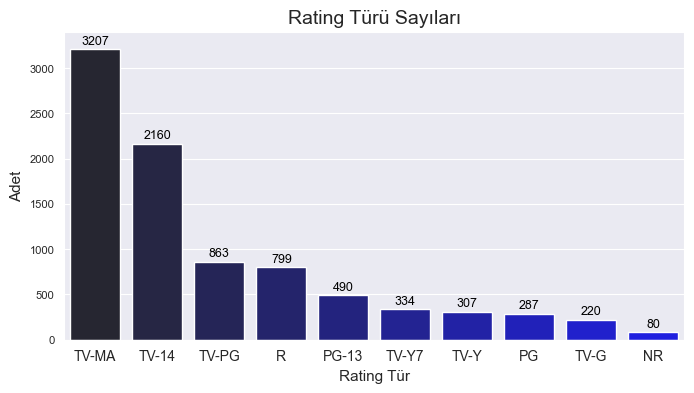

In [38]:
sns.set_style("darkgrid")
fig, ax = plt.subplots(figsize=(8,4))


sns.barplot(x=popular_rating.index, y=popular_rating.values, hue=popular_rating.index,
            palette="dark:blue", ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=1.6, color="black", fontsize=9)
ax.set_title("Rating Türü Sayıları",fontsize=14)
ax.tick_params(axis="y", labelsize=8) 
ax.set_ylim([0,3400])
ax.set_ylabel("Adet",fontsize=11)
ax.set_xlabel("Rating Tür",fontsize=11)
plt.show()

Netflixte içeriklerin rating değerlendirme türlerinde TV-MA ve TV-14 ratinglerinin  
bütün ratinglerin yaklaşık %61 ini oluşturmaktadır.

In [43]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,movie_duration,season_count,added_day_name,added_year,added_month
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,NaN,Saturday,2021,September
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2,Friday,2021,September


### Soru 6: En çok içerik üreten ülkeler hangileri?

In [50]:
group_countr= df.groupby("country")["type"].count().sort_values(ascending=False).head(10)
group_countr

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: type, dtype: int64

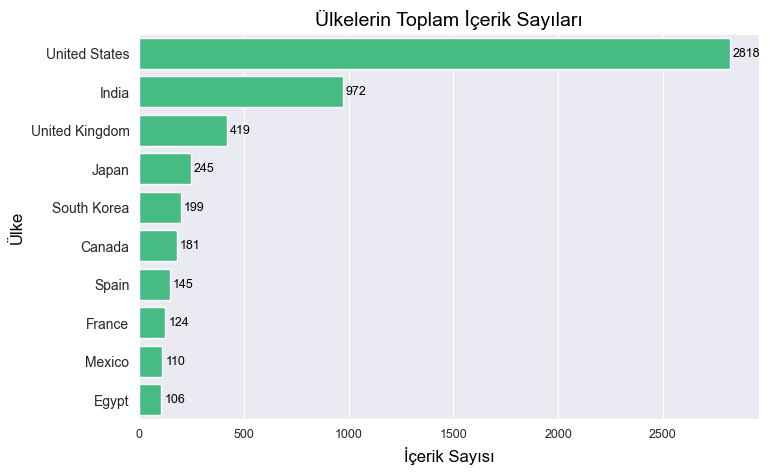

In [59]:
fig , ax = plt.subplots(figsize=(8,5))
sns.barplot(x=group_countr.values,y=group_countr.index, ax=ax, color="#33CE83FF")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2.2, color="black", fontsize=9)
ax.set_title("Ülkelerin Toplam İçerik Sayıları",color="black", fontsize=14)
ax.set_ylabel("Ülke",color="black", fontsize=12)
ax.set_xlabel("İçerik Sayısı",color="black", fontsize=12)
ax.tick_params(axis="x", labelsize=9)
plt.show()

Netflixte ülkelerin içerik sayılarını incelediğimizde United States'in sektörün en büyük  
aktörü olduğunu görmekteyiz, ardından Hindistan'ın içerik sayısı göze batmaktadır.

### Genel Özet

Yaptığımız analizimizi özetlersek ve bulduğumuz çıktılara bakarsak;  
Netflix kütüphanesi film ağılıklıdır, içerik sayısı 2025 yılından itibaren artarak  
2018-2019 yıllarında tavan yapmıştır, en çok içerik üreten ülke USA'dir.
